In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

# Membaca dataset.
# Jika path lokal tidak ditemukan, kode akan mencoba membaca file CSV dari folder notebook.
try:
    data = pd.read_csv(r"C:\Users\MSI1\Documents\1Dibimbing.id\Mini Project Marketing &Growth Analytics_Izzan Muhammad Fa'iz\marketing_campaign_dataset.csv")
except FileNotFoundError:
    data = pd.read_csv("marketing_campaign_dataset.csv")

dfraw = pd.DataFrame(data)

# Buat copy untuk memperbaiki data
df = dfraw.copy()

In [2]:
# Menampilkan 5 data pertama
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,16174,6.29,Chicago,Spanish,506,1922,6,Health & Wellness,1/1/2021
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,11566,5.61,New York,German,116,7523,7,Fashionistas,1/2/2021
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,10200,7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,1/3/2021
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,12724,5.55,Miami,Mandarin,217,1820,7,Health & Wellness,1/4/2021
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,16452,6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,1/5/2021


In [3]:
# Menampilkan 5 data terakhir
df.tail()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
99995,99996,NexGen Systems,Display,Women 35-44,15 days,Google Ads,0.02,8867,6.17,Miami,English,443,2572,8,Outdoor Adventurers,12/17/2021
99996,99997,DataTech Solutions,Display,Men 18-24,60 days,YouTube,0.14,13180,6.85,Chicago,French,214,4914,5,Outdoor Adventurers,12/18/2021
99997,99998,Alpha Innovations,Search,Men 25-34,45 days,YouTube,0.03,11259,7.47,Houston,Mandarin,832,9414,3,Fashionistas,12/19/2021
99998,99999,TechCorp,Social Media,Men 18-24,30 days,Email,0.12,8142,7.98,Houston,Mandarin,229,9395,5,Fashionistas,12/20/2021
99999,100000,NexGen Systems,Email,Women 25-34,15 days,YouTube,0.05,14683,6.96,Miami,Spanish,321,2848,2,Fashionistas,12/21/2021


In [4]:
# Melihat dimensi dataset
df.shape

(100000, 16)

Jumlah baris sekitar 10.000 dengan 16 kolom.

In [5]:
# Pengecekan struktur data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       100000 non-null  int64  
 1   Company           100000 non-null  object 
 2   Campaign_Type     100000 non-null  object 
 3   Target_Audience   100000 non-null  object 
 4   Duration          100000 non-null  object 
 5   Channel_Used      100000 non-null  object 
 6   Conversion_Rate   100000 non-null  float64
 7   Acquisition_Cost  100000 non-null  int64  
 8   ROI               100000 non-null  float64
 9   Location          100000 non-null  object 
 10  Language          100000 non-null  object 
 11  Clicks            100000 non-null  int64  
 12  Impressions       100000 non-null  int64  
 13  Engagement_Score  100000 non-null  int64  
 14  Customer_Segment  100000 non-null  object 
 15  Date              100000 non-null  object 
dtypes: float64(2), int64(

In [6]:
# Distribusi data numerik

df.describe()

,Campaign_ID,Conversion_Rate,Acquisition_Cost,ROI,Clicks,Impressions,Engagement_Score
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,0.080065,12515.846250,5.001896,549.167260,5510.295570,5.494140
std,28867.657797,0.040584,4334.888936,1.734910,259.881738,2597.237107,2.869597
min,1.000000,0.010000,5000.000000,2.000000,100.000000,1000.000000,1.000000
25%,25000.750000,0.050000,8774.000000,3.500000,324.000000,3274.000000,3.000000
50%,50000.500000,0.080000,12508.000000,5.000000,548.000000,5519.000000,5.000000
75%,75000.250000,0.110000,16266.000000,6.510000,774.000000,7757.000000,8.000000
max,100000.000000,0.150000,20000.000000,8.000000,1000.000000,10000.000000,10.000000


In [7]:
# Missing value

missing = df.isnull().sum()

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': round((missing/len(df))*100,2)
})

missing_df.sort_values(
    by='Missing Count',
    ascending=False
)

,Missing Count,Missing Percentage
Campaign_ID,0,0.0
Company,0,0.0
Campaign_Type,0,0.0
Target_Audience,0,0.0
Duration,0,0.0
Channel_Used,0,0.0
Conversion_Rate,0,0.0
Acquisition_Cost,0,0.0
ROI,0,0.0
Location,0,0.0


In [8]:
duplicate_count = df.duplicated().sum()

print(f"Jumlah data duplikat : {duplicate_count}")

Jumlah data duplikat : 0


In [9]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(df[col].unique())


Company
['Innovate Industries' 'NexGen Systems' 'Alpha Innovations'
 'DataTech Solutions' 'TechCorp']

Campaign_Type
['Email' 'Influencer' 'Display' 'Search' 'Social Media']

Target_Audience
['Men 18-24' 'Women 35-44' 'Men 25-34' 'All Ages' 'Women 25-34']

Duration
['30 days' '60 days' '15 days' '45 days']

Channel_Used
['Google Ads' 'YouTube' 'Instagram' 'Website' 'Facebook' 'Email']

Location
['Chicago' 'New York' 'Los Angeles' 'Miami' 'Houston']

Language
['Spanish' 'German' 'French' 'Mandarin' 'English']

Customer_Segment
['Health & Wellness' 'Fashionistas' 'Outdoor Adventurers' 'Foodies'
 'Tech Enthusiasts']

Date
['1/1/2021' '1/2/2021' '1/3/2021' '1/4/2021' '1/5/2021' '1/6/2021'
 '1/7/2021' '1/8/2021' '1/9/2021' '1/10/2021' '1/11/2021' '1/12/2021'
 '1/13/2021' '1/14/2021' '1/15/2021' '1/16/2021' '1/17/2021' '1/18/2021'
 '1/19/2021' '1/20/2021' '1/21/2021' '1/22/2021' '1/23/2021' '1/24/2021'
 '1/25/2021' '1/26/2021' '1/27/2021' '1/28/2021' '1/29/2021' '1/30/2021'
 '1/31/2021' '2/

In [10]:
# Menghilangkan spasi berlebih.

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

In [11]:
# Standarisasi huruf

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.title()

In [12]:
# Konversi Tanggal

df['Date'] = pd.to_datetime(df['Date'])

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Campaign_ID       100000 non-null  int64         
 1   Company           100000 non-null  object        
 2   Campaign_Type     100000 non-null  object        
 3   Target_Audience   100000 non-null  object        
 4   Duration          100000 non-null  object        
 5   Channel_Used      100000 non-null  object        
 6   Conversion_Rate   100000 non-null  float64       
 7   Acquisition_Cost  100000 non-null  int64         
 8   ROI               100000 non-null  float64       
 9   Location          100000 non-null  object        
 10  Language          100000 non-null  object        
 11  Clicks            100000 non-null  int64         
 12  Impressions       100000 non-null  int64         
 13  Engagement_Score  100000 non-null  int64         
 14  Custo

In [14]:
# OUTLIER

numeric_cols = df.select_dtypes(include=np.number).columns
numeric_cols

Index(['Campaign_ID', 'Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Clicks',
       'Impressions', 'Engagement_Score'],
      dtype='object')

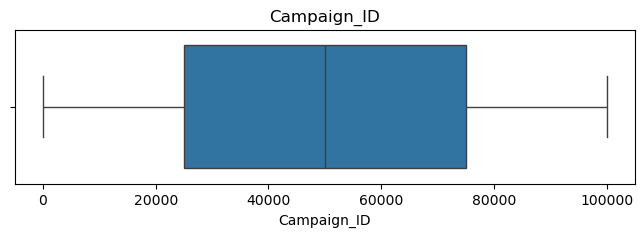

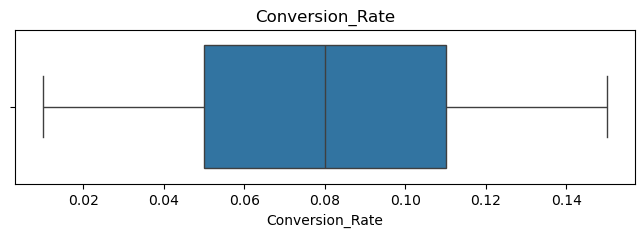

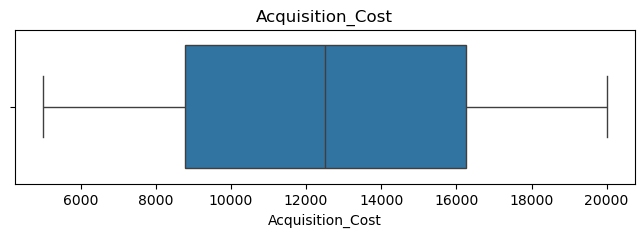

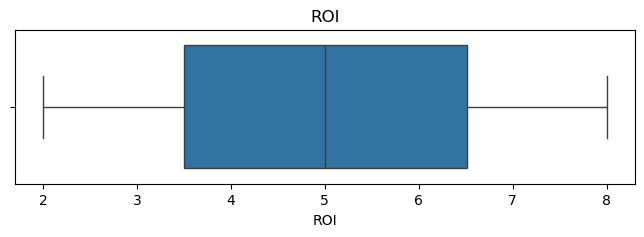

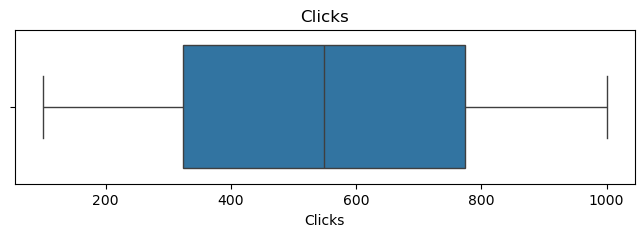

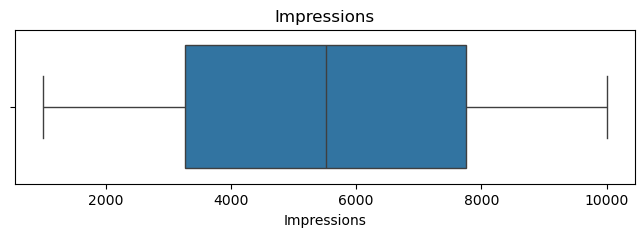

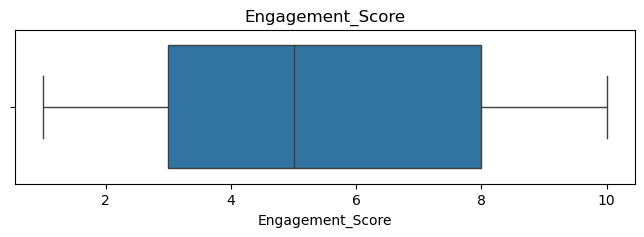

In [15]:
# Boxplot untuk mendeteksi outlier pada setiap kolom numerik

for col in numeric_cols:

    plt.figure(figsize=(8,2))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

In [16]:
# IQR
def detect_outlier_iqr(df,col):

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outlier = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    return len(outlier)


for col in numeric_cols:

    print(
        col,
        detect_outlier_iqr(df,col)
    )

Campaign_ID 0
Conversion_Rate 0
Acquisition_Cost 0
ROI 0
Clicks 0
Impressions 0
Engagement_Score 0


In [17]:
from scipy.stats import normaltest

# ==========================================
# D'Agostino-Pearson Normality Test
# ==========================================

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

results = []

for col in num_cols:
    statistic, p_value = normaltest(df[col].dropna())

    results.append({
        "Column": col,
        "Statistic": statistic,
        "P-Value": p_value,
        "Normal Distribution": "Yes" if p_value > 0.05 else "No"
    })

normality_df = pd.DataFrame(results)

normality_df["Statistic"] = normality_df["Statistic"].round(2)
normality_df["P-Value"] = normality_df["P-Value"].apply(lambda x: f"{x:.5f}")

normality_df

print("=== D'Agostino-Pearson Normality Test ===\n")

for _, row in normality_df.iterrows():
    print(f"{row['Column']}")
    print(f"Statistic : {row['Statistic']}")
    print(f"P-value   : {row['P-Value']}")

    if row["Normal Distribution"] == "Yes":
        print("Conclusion: Data is normally distributed.\n")
    else:
        print("Conclusion: Data is NOT normally distributed.\n")

=== D'Agostino-Pearson Normality Test ===

Campaign_ID
Statistic : 88655.89
P-value   : 0.00000
Conclusion: Data is NOT normally distributed.

Conversion_Rate
Statistic : 70753.86
P-value   : 0.00000
Conclusion: Data is NOT normally distributed.

Acquisition_Cost
Statistic : 88019.01
P-value   : 0.00000
Conclusion: Data is NOT normally distributed.

ROI
Statistic : 89225.02
P-value   : 0.00000
Conclusion: Data is NOT normally distributed.

Clicks
Statistic : 87663.64
P-value   : 0.00000
Conclusion: Data is NOT normally distributed.

Impressions
Statistic : 84246.34
P-value   : 0.00000
Conclusion: Data is NOT normally distributed.

Engagement_Score
Statistic : 111826.31
P-value   : 0.00000
Conclusion: Data is NOT normally distributed.



In [18]:
from scipy.stats import shapiro

print("=== UJI NORMALITAS SHAPIRO-WILK (SAMPLE 5.000 BARIS) ===")
for col in num_cols:
    # Mengambil sampel acak 5000 baris karena limitasi library shapiro
    sample_data = df[col].sample(5000, random_state=42)
    stat, p_value = shapiro(sample_data)
    
    # Penentuan keputusan berdasarkan alpha = 0.05
    status = "Berdistribusi NORMAL" if p_value > 0.05 else "TIDAK Normal"
    print(f"Kolom {col:18} -> p-value: {p_value:.5f} | Kesimpulan: {status}")

=== UJI NORMALITAS SHAPIRO-WILK (SAMPLE 5.000 BARIS) ===
Kolom Campaign_ID        -> p-value: 0.00000 | Kesimpulan: TIDAK Normal
Kolom Conversion_Rate    -> p-value: 0.00000 | Kesimpulan: TIDAK Normal
Kolom Acquisition_Cost   -> p-value: 0.00000 | Kesimpulan: TIDAK Normal
Kolom ROI                -> p-value: 0.00000 | Kesimpulan: TIDAK Normal
Kolom Clicks             -> p-value: 0.00000 | Kesimpulan: TIDAK Normal
Kolom Impressions        -> p-value: 0.00000 | Kesimpulan: TIDAK Normal
Kolom Engagement_Score   -> p-value: 0.00000 | Kesimpulan: TIDAK Normal


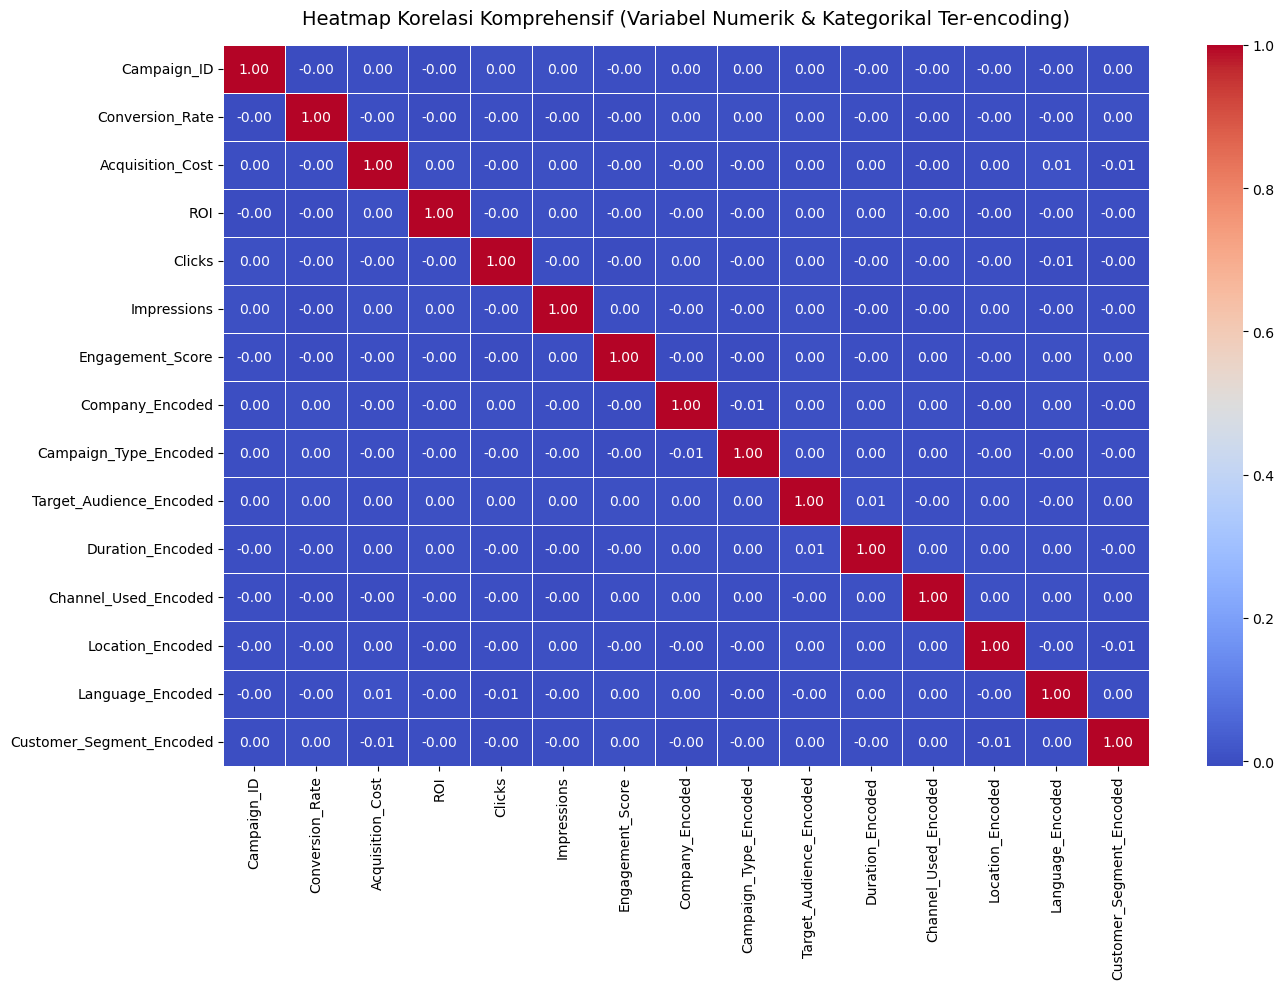

In [19]:
from sklearn.preprocessing import LabelEncoder

# Copy dataframe asli agar data mentah tidak rusak
df_processed = df.copy()

# CATEGORICAL ENCODING (Label Encoding)
le = LabelEncoder()
cat_cols_to_encode = ['Company', 'Campaign_Type', 'Target_Audience', 'Duration', 'Channel_Used', 'Location', 'Language', 'Customer_Segment']

for col in cat_cols_to_encode:
    # Membuat kolom baru dengan akhiran '_Encoded'
    df_processed[f'{col}_Encoded'] = le.fit_transform(df_processed[col])

# Mengambil semua kolom yang sudah berbentuk angka (Numerik asli + Encoded)
# all_numeric_features = num_cols_to_scale + [f'{col}_Encoded' for col in cat_cols_to_encode]
full_correlation_matrix = df_processed.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(full_correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar=True)
plt.title('Heatmap Korelasi Komprehensif (Variabel Numerik & Kategorikal Ter-encoding)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

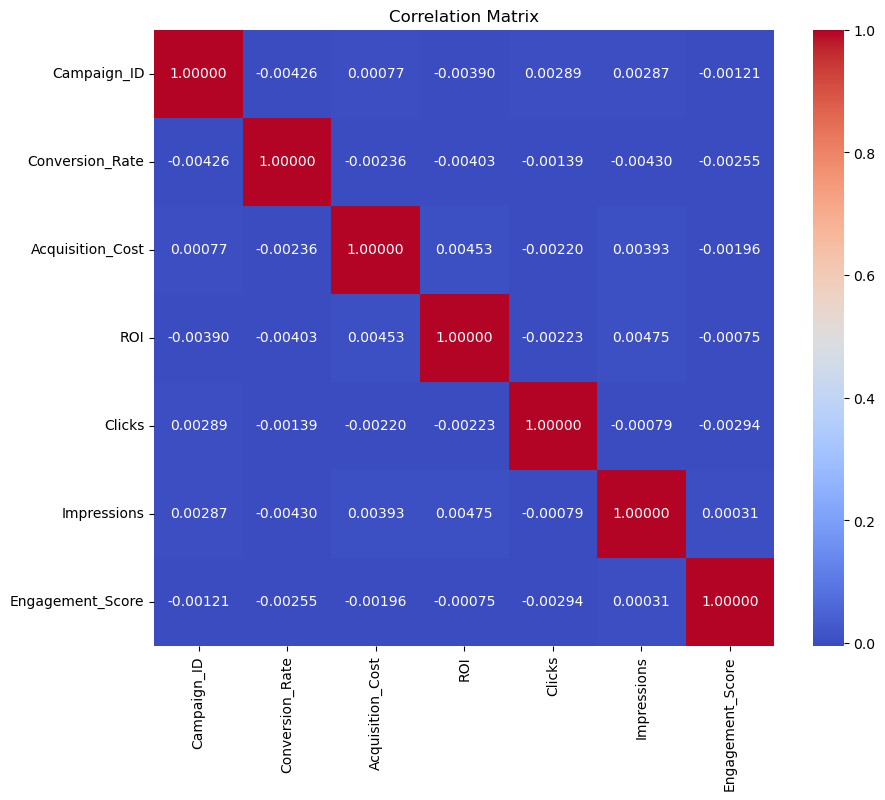

In [20]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.5f')

plt.title("Correlation Matrix")

plt.show()

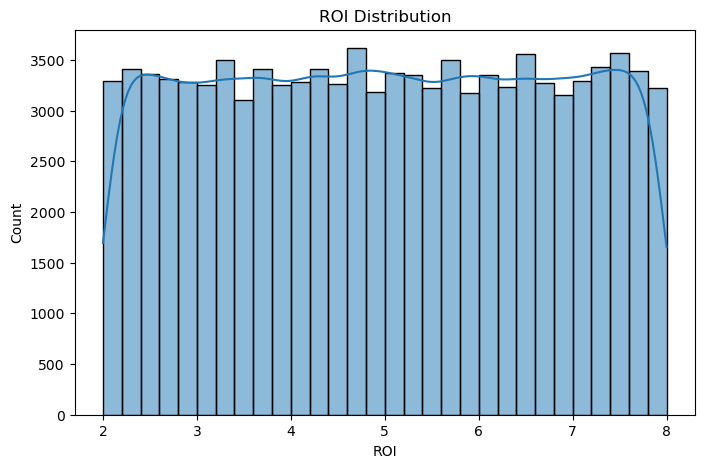

In [ ]:
# Distribusi ROI

plt.figure(figsize=(8,5))

sns.histplot(
    df['ROI'],
    bins=30,
    kde=True
)

plt.title('ROI Distribution')
plt.show()

<Axes: xlabel='Campaign_Type'>

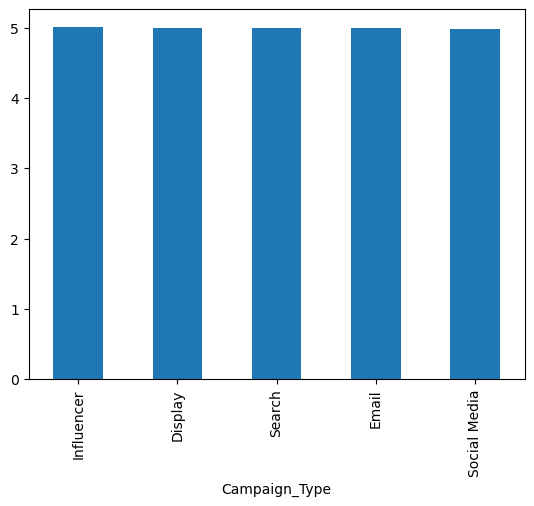

In [ ]:
# ROI berdasarkan Campaign Type

campaign_roi = (
    df.groupby('Campaign_Type')['ROI']
      .mean()
      .sort_values(ascending=False)
)

campaign_roi.plot(
    kind='bar'
)

<Axes: xlabel='Channel_Used'>

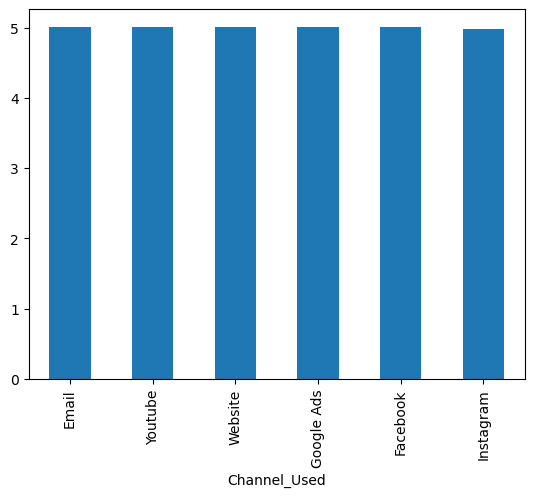

In [26]:
# ROI berdasarkan Channel Used

channel_roi = (
    df.groupby('Channel_Used')['ROI']
      .mean()
      .sort_values(ascending=False)
)

channel_roi.plot(
    kind='bar'
)

<Axes: xlabel='Channel_Used', ylabel='Campaign_Type'>

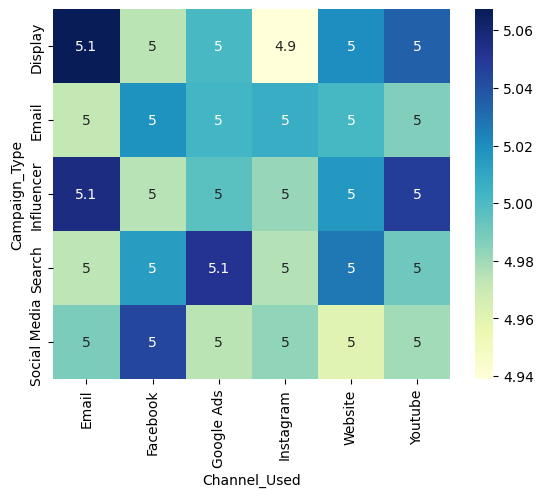

In [27]:
pivot = df.pivot_table(
    values='ROI',
    index='Campaign_Type',
    columns='Channel_Used',
    aggfunc='mean'
)

sns.heatmap(
    pivot,
    annot=True,
    cmap='YlGnBu'
)

In [22]:
df.to_csv(
    'marketing_campaign_cleaned.csv',
    index=False
)